In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pwd

/home/stelios/ais_USA


## Create local datasets

In [4]:
pd.read_html('https://api.vtexplorer.com/docs/ref-aistypes.html')[0].to_csv('ais_types.csv',index=False)

In [5]:
pd.read_html('https://api.vtexplorer.com/docs/ref-navstat.html')[0].to_csv('ref_navstat.csv',index=False)

## Exploratory Data Analysis

In [3]:
ais_ships_df=pd.read_csv('../AIS/AIS_2022_03_31.csv')

In [4]:
ais_ships_df

,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,367702220,2022-03-31T00:00:01,29.78763,-95.08070,0.1,226.5,340.0,JOE B WARD,NaN,WDI4808,31.0,12.0,21.0,8.0,NaN,57.0,A
1,671226100,2022-03-31T00:00:01,25.77626,-80.20320,3.2,143.7,511.0,RELIANCE II,IMO9221322,5VHS7,79.0,0.0,52.0,12.0,2.5,70.0,A
2,367767250,2022-03-31T00:00:01,29.31623,-94.78829,4.5,228.1,511.0,GLEN K,NaN,WDJ3358,52.0,0.0,0.0,0.0,0.0,52.0,A
3,338327436,2022-03-31T00:00:03,47.29634,-122.42233,0.0,360.0,511.0,COOL KAT,IMO0000000,NaN,36.0,NaN,15.0,3.0,NaN,NaN,B
4,367452810,2022-03-31T00:00:06,29.32824,-94.77391,2.6,319.2,511.0,JOHN W JOHNSON,IMO9602344,WDF4516,60.0,0.0,80.0,19.0,3.0,60.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167041,636018637,2022-03-31T00:22:46,12.52147,141.68964,13.4,324.3,327.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,A
7167042,370101000,2022-03-31T08:37:49,10.91870,142.85554,13.5,330.4,330.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,A
7167043,370101000,2022-03-31T09:48:29,11.14859,142.71331,13.5,325.2,329.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,A
7167044,370101000,2022-03-31T19:15:28,12.93339,141.57638,13.1,326.3,330.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,A


<AxesSubplot: xlabel='parsed_timestamp'>

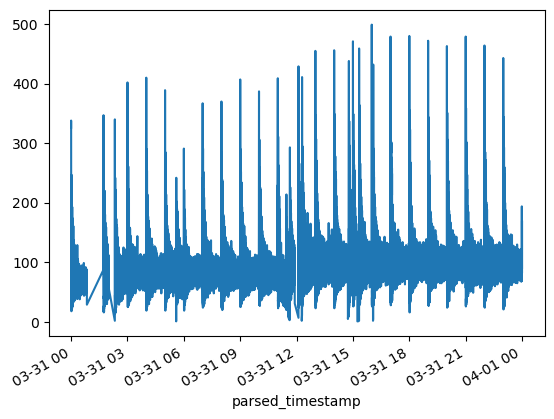

In [5]:
(ais_ships_df
 .assign(parsed_timestamp=ais_ships_df.BaseDateTime.pipe(pd.to_datetime))
 .groupby('parsed_timestamp')
 .count()
 .MMSI
 .plot()
)

<AxesSubplot: xlabel='parsed_timestamp'>

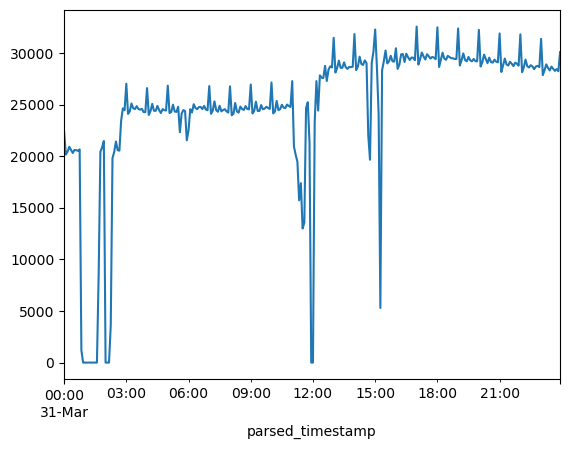

In [6]:
(ais_ships_df
 .assign(parsed_timestamp=ais_ships_df.BaseDateTime.pipe(pd.to_datetime))
 .groupby('parsed_timestamp')
 .count()
 .MMSI
 .resample('5min')
 .sum()
 .plot()
)

Some weird gaps, plateau then increase

<AxesSubplot: xlabel='parsed_timestamp'>

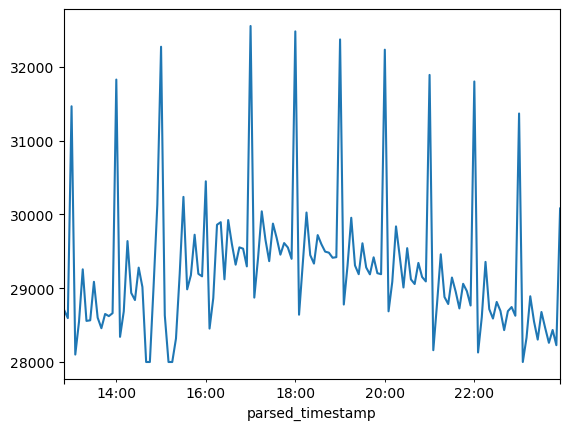

In [7]:
(ais_ships_df
 .assign(parsed_timestamp=ais_ships_df.BaseDateTime.pipe(pd.to_datetime))
 .groupby('parsed_timestamp')
 .count()
 .MMSI
 .resample('5min')
 .sum()
 .loc['2022-03-31 12:50':]
 .clip(lower=28_000, upper=35_000)
 .plot()
)

hourly spikes?

In [11]:
(ais_ships_df
 .assign(parsed_timestamp=ais_ships_df.BaseDateTime.pipe(pd.to_datetime))
 .groupby('parsed_timestamp')
 .count()
 .MMSI
 .resample('5min')
 .sum()
 .loc['2022-03-31 12:50':]
 .sort_values(ascending=False)
 .iloc[0:11]
)

parsed_timestamp
2022-03-31 17:00:00    32554
2022-03-31 18:00:00    32481
2022-03-31 19:00:00    32372
2022-03-31 15:00:00    32273
2022-03-31 20:00:00    32233
2022-03-31 21:00:00    31891
2022-03-31 14:00:00    31828
2022-03-31 22:00:00    31802
2022-03-31 13:00:00    31466
2022-03-31 23:00:00    31368
2022-03-31 16:00:00    30449
Name: MMSI, dtype: int64

<AxesSubplot: xlabel='Lag', ylabel='Autocorrelation'>

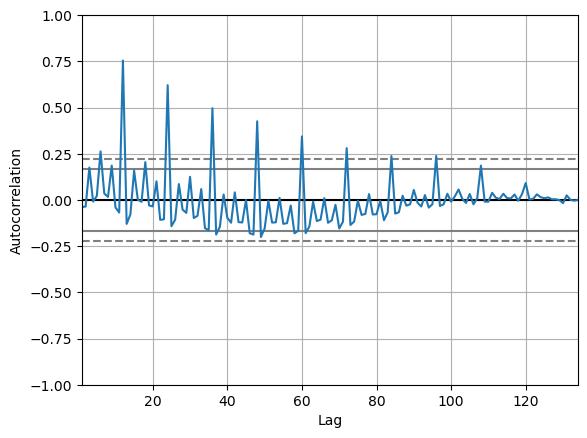

In [12]:
pd.plotting.autocorrelation_plot(ais_ships_df
 .assign(parsed_timestamp=ais_ships_df.BaseDateTime.pipe(pd.to_datetime))
 .groupby('parsed_timestamp')
 .count()
 .MMSI
 .resample('5min')
 .sum()
 .loc['2022-03-31 12:50':]
 .clip(lower=28_000, upper=35_000)
)

Hourly spikes at 12 x 5min, 24 x 5 min etc. 60 is the one aligned with grid.

In [13]:
ais_ships_df.count()

MMSI                7167046
BaseDateTime        7167046
LAT                 7167046
LON                 7167046
SOG                 7167046
COG                 7167046
Heading             7167046
VesselName          7149845
IMO                 3798262
CallSign            6333703
VesselType          7166229
Status              5538308
Length              6728850
Width               5992969
Draft               2705725
Cargo               5542099
TransceiverClass    7167046
dtype: int64

<AxesSubplot: ylabel='TransceiverClass'>

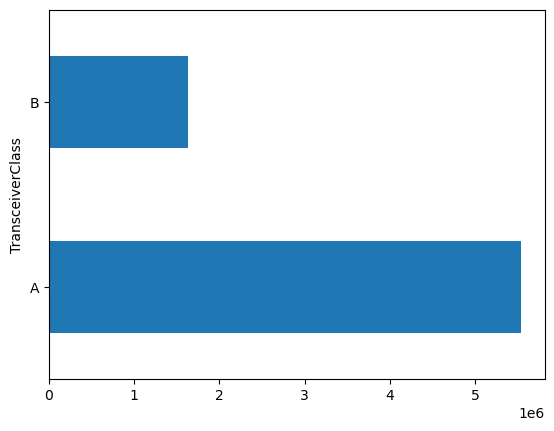

In [14]:
ais_ships_df.groupby('TransceiverClass').count()['MMSI'].plot(kind='barh')

array([[<AxesSubplot: title={'center': 'MMSI'}>,
        <AxesSubplot: title={'center': 'LAT'}>,
        <AxesSubplot: title={'center': 'LON'}>],
       [<AxesSubplot: title={'center': 'SOG'}>,
        <AxesSubplot: title={'center': 'COG'}>,
        <AxesSubplot: title={'center': 'Heading'}>],
       [<AxesSubplot: title={'center': 'VesselType'}>,
        <AxesSubplot: title={'center': 'Status'}>,
        <AxesSubplot: title={'center': 'Length'}>],
       [<AxesSubplot: title={'center': 'Width'}>,
        <AxesSubplot: title={'center': 'Draft'}>,
        <AxesSubplot: title={'center': 'Cargo'}>]], dtype=object)

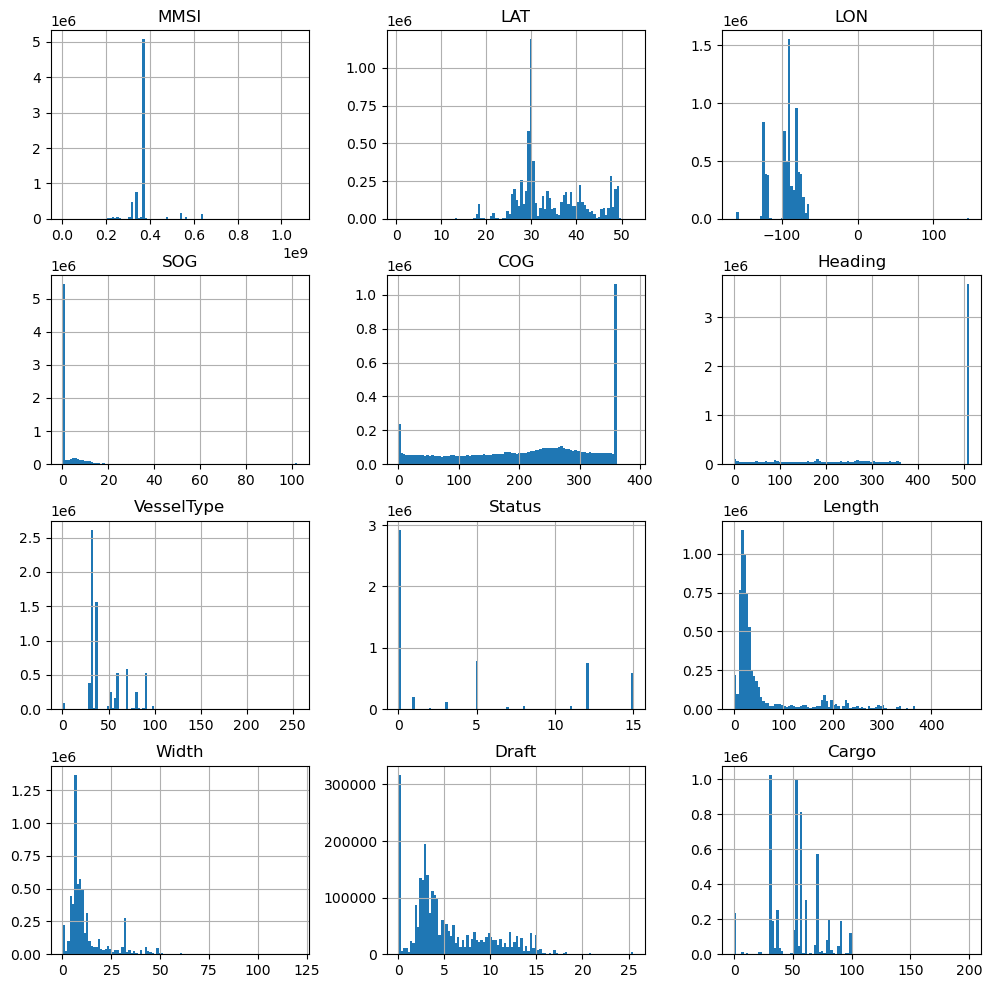

In [15]:
ais_ships_df.hist(bins=100,figsize=[12,12])

> Alasdair Rae  1 week ago • LinkedIn
How do you map north sea infrastructure if you don't actually have a dataset of north sea infrastructure? You use one of my favourite datasets (AIS ship tracks) and then look for "non-port service craft" and just show those - then you can see the volume of traffic in and out of Aberdeen, wind farm locations and all sorts of other fascinating things

> Rodney Forster Hull Marine Laboratory, School of Environmental Sciences, University of Hull
1w
That seems to be excluding the offshore wind traffic. The wind cats are tagged with ‘high speed craft’ or similar in AIS. The hot spot locations are nearly all gas and oil platforms.

for uk https://environment.data.gov.uk/dataset/ffb7d2d8-2e13-487c-a17f-7abc0f116d50

Need lookup for vessel types. suspicious spikes

## Lookups
### analyse Vessel Types

In [16]:
ais_types=pd.read_csv('ais_types.csv')

In [17]:
ais_types.set_index('Type Code')

,Description
Type Code,
0,Not available (default)
1-19,Reserved for future use
20,"Wing in ground (WIG), all ships of this type"
21,"Wing in ground (WIG), Hazardous category A"
22,"Wing in ground (WIG), Hazardous category B"
...,...
95,"Other Type, Reserved for future use"
96,"Other Type, Reserved for future use"
97,"Other Type, Reserved for future use"


Has "high speed craft" but not "non port service craft".

In [18]:
ais_types.set_index('Type Code').drop(index='1-19')

,Description
Type Code,
0,Not available (default)
20,"Wing in ground (WIG), all ships of this type"
21,"Wing in ground (WIG), Hazardous category A"
22,"Wing in ground (WIG), Hazardous category B"
23,"Wing in ground (WIG), Hazardous category C"
...,...
95,"Other Type, Reserved for future use"
96,"Other Type, Reserved for future use"
97,"Other Type, Reserved for future use"


In [19]:
pd.interval_range(start=1,end=19,freq=1)

IntervalIndex([(1, 2], (2, 3], (3, 4], (4, 5], (5, 6] ... (14, 15], (15, 16], (16, 17], (17, 18], (18, 19]], dtype='interval[int64, right]')

In [25]:
(ais_ships_df
 .groupby('VesselType')
 .count()
 [['MMSI']]
 .merge(ais_types.set_index('Type Code').drop(index='1-19'),left_index=True, right_index=True, how='left')
 .sort_values('MMSI',ascending=False)
 #.plot(kind="barh", figsize=[12,10], logx=True)
)

,MMSI,Description
VesselType,,
31.0,2560218,NaN
37.0,1283684,NaN
70.0,540352,NaN
60.0,530078,NaN
90.0,521006,NaN
...,...,...
76.0,406,NaN
67.0,332,NaN
83.0,287,NaN


255 not in the lookup

### Navigational status

In [21]:
ais_status=pd.read_csv('ref_navstat.csv')

In [22]:
ais_status.set_index('Navigation Status')

,Description
Navigation Status,
0,Under way using engine
1,At anchor
2,Not under command
3,Restricted manoeuverability
4,Constrained by her draught
5,Moored
6,Aground
7,Engaged in Fishing
8,Under way sailing


<AxesSubplot: ylabel='Description'>

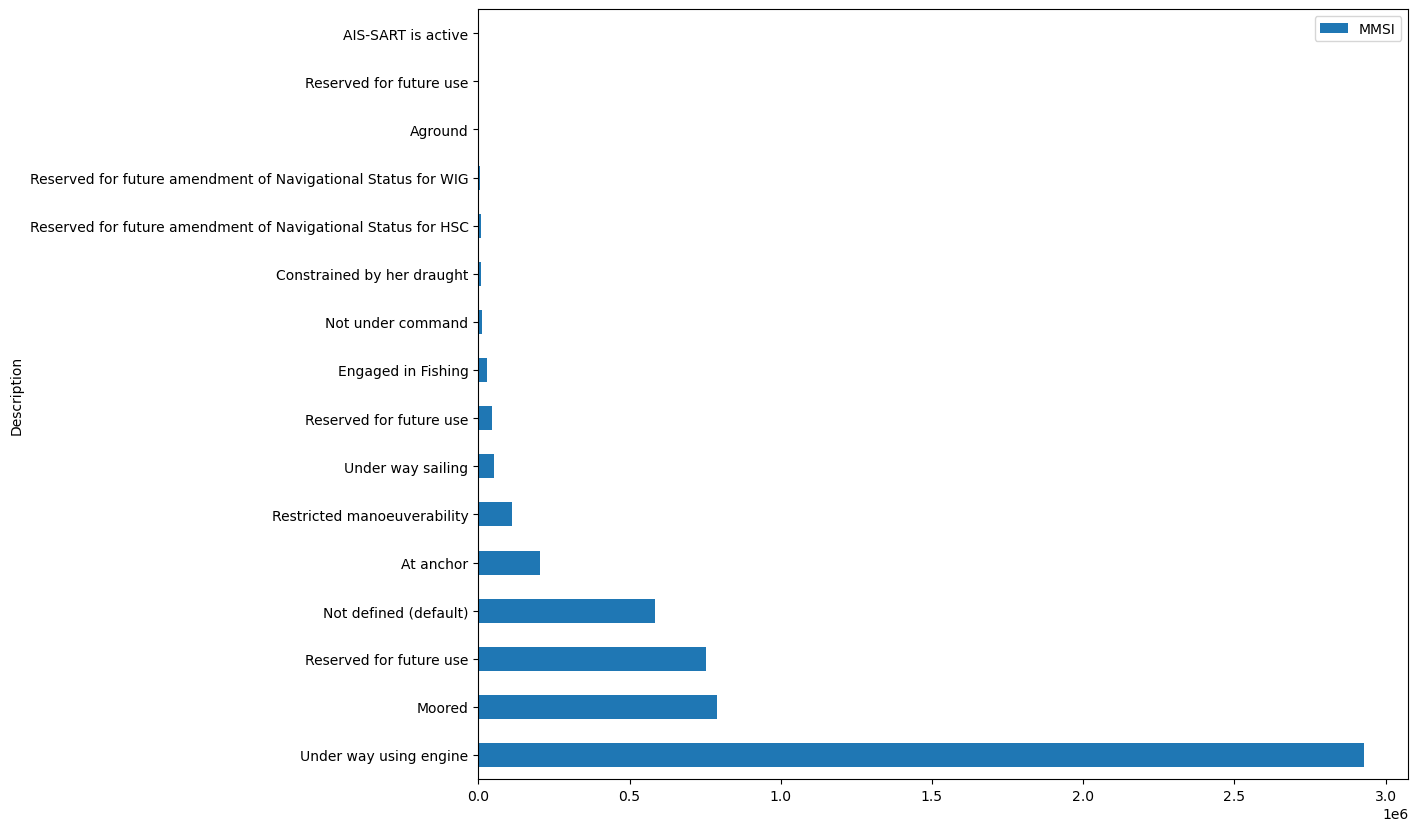

In [50]:
(ais_ships_df
 .groupby('Status')
 .count()
 [['MMSI']]
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True, how='left')
 .reset_index()
 .drop(columns='Status')
 .set_index('Description')
 .sort_values('MMSI',ascending=False)
 .plot(kind="barh", figsize=[12,10])
)

## Outliers/Spikes

### Speed over ground

In [21]:
ais_ships_df.SOG.max()

102.3

In [22]:
ais_ships_df.groupby('SOG').count().MMSI.sort_values(ascending=False).iloc[0:15]

SOG
0.0      4358545
0.1       643249
0.2       144087
0.3        77594
0.4        54276
0.5        39686
0.6        30676
0.7        27521
0.8        22851
102.3      22587
0.9        20133
1.0        18629
4.5        18324
4.9        18280
4.7        18214
Name: MMSI, dtype: int64

Might be true for speed 0 when anchored and at port. What about 102.3?

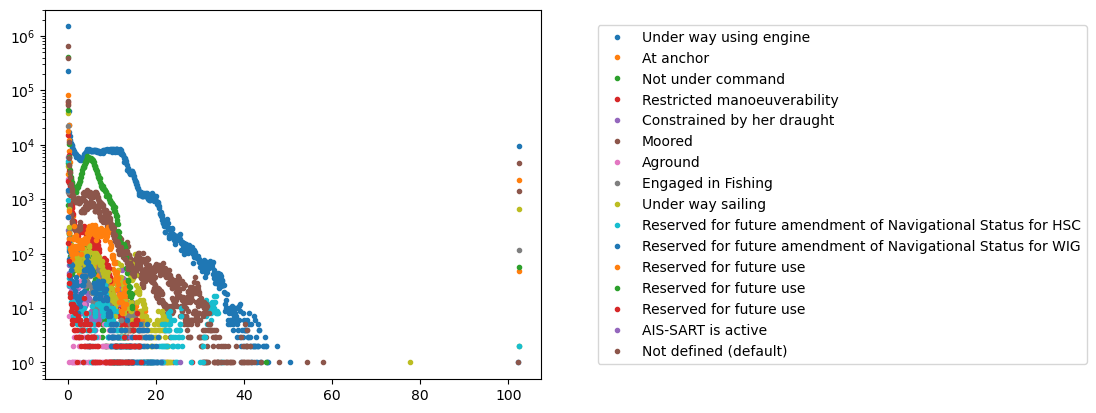

In [35]:
(ais_ships_df
 .groupby(['Status','SOG'])
 .count()
 .MMSI
 .unstack()
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True)
 .reset_index()
 .drop(columns='Status')
 .set_index('Description')
 .T
 .sort_index()
 .plot(logy=True, marker='.',ls='')#.sort_values(ascending=False)#.iloc[0:15]
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

102.3 a physically impossible outlier/magic number? But number near 80 also an outlier

In [36]:
(ais_ships_df
 .groupby(['Status','SOG'])
 .count()
 .MMSI
 .unstack()
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True)
 .reset_index()
 .drop(columns='Status')
 .set_index('Description')
 .T
 .sort_index()
)

Description,Under way using engine,At anchor,Not under command,Restricted manoeuverability,Constrained by her draught,Moored,Aground,Engaged in Fishing,Under way sailing,Reserved for future amendment of Navigational Status for HSC,Reserved for future amendment of Navigational Status for WIG,Reserved for future use,Reserved for future use,Reserved for future use,AIS-SART is active,Not defined (default)
0.0,1492044.0,83587.0,4667.0,61999.0,5856.0,652010.0,2312.0,22576.0,38077.0,5013.0,1482.0,17606.0,402133.0,2171.0,NaN,397684.0
0.1,229819.0,55796.0,784.0,14860.0,272.0,62911.0,475.0,1375.0,4006.0,984.0,470.0,2967.0,42996.0,159.0,NaN,53945.0
0.2,41314.0,22807.0,252.0,6533.0,63.0,5884.0,7.0,277.0,648.0,134.0,166.0,618.0,10465.0,72.0,NaN,11450.0
0.3,22852.0,12479.0,241.0,3774.0,45.0,2011.0,NaN,192.0,308.0,36.0,114.0,237.0,6043.0,40.0,NaN,5746.0
0.4,17272.0,7550.0,232.0,3308.0,25.0,1233.0,1.0,122.0,236.0,26.0,81.0,184.0,4337.0,29.0,NaN,4295.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
57.9,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102.2,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Outliers are 77.7, 102.2 and 102.3

In [58]:
(ais_ships_df
 .groupby(['Status','SOG'])
 .count()
 .MMSI
 .unstack()
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True)
 .reset_index()
 .drop(columns='Status')
 .set_index('Description')
 .T
 .sort_index()
 .loc[77.7:]
 .T
 .dropna(axis='index',how='all')
)

,77.7,102.2,102.3
Description,,,
Under way using engine,NaN,1.0,9311.0
At anchor,NaN,NaN,48.0
Not under command,NaN,NaN,2.0
Moored,NaN,1.0,4653.0
Engaged in Fishing,NaN,NaN,116.0
Under way sailing,1.0,NaN,650.0
Reserved for future amendment of Navigational Status for HSC,NaN,NaN,2.0
Reserved for future use,NaN,NaN,2278.0
Reserved for future use,NaN,NaN,58.0


77.7 and 102.2 just 1-2 datapoints. 102.3 clearly a magic number.

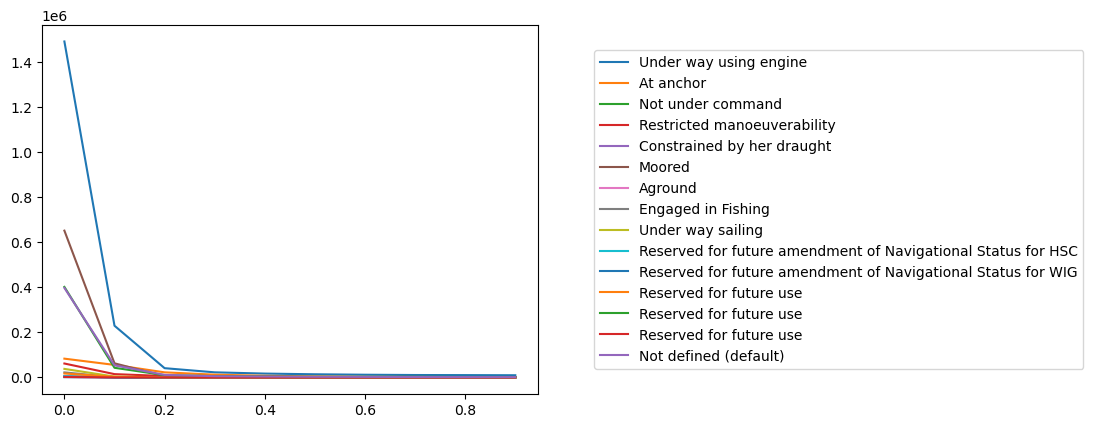

In [46]:
(ais_ships_df
 .query('SOG<1')
 .groupby(['Status','SOG'])
 .count()
 .MMSI
 .unstack()
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True)
 .reset_index()
 .drop(columns='index')
 .set_index('Description')
 .T
 .sort_index()
 .plot()
 .legend(loc='center left',bbox_to_anchor=(1.1, 0.5))
)

Underway or moored most popular, followed by?

In [55]:
(ais_ships_df
 .query('SOG<1')
 .groupby(['Status','SOG'])
 .count()
 .MMSI
 .unstack()
 .merge(ais_status.set_index('Navigation Status'),left_index=True, right_index=True)
 .reset_index()
 .drop(columns='index')
 .set_index('Description')
 .T
 .sort_index()
 .loc[0.0]
 .sort_values(ascending=False)
)

Description
Under way using engine                                          1492044.0
Moored                                                           652010.0
Reserved for future use                                          402133.0
Not defined (default)                                            397684.0
At anchor                                                         83587.0
Restricted manoeuverability                                       61999.0
Under way sailing                                                 38077.0
Engaged in Fishing                                                22576.0
Reserved for future use                                           17606.0
Constrained by her draught                                         5856.0
Reserved for future amendment of Navigational Status for HSC       5013.0
Not under command                                                  4667.0
Aground                                                            2312.0
Reserved for future use   

### Heading

In [25]:
ais_ships_df.Heading.max()

511.0

> HEADING	integer	Heading (degrees) of the vessel's hull. A value of 511 indicates there is no heading data.

https://api.vtexplorer.com/docs/response-ais.html

In [26]:
ais_ships_df.groupby('Heading').count().MMSI.sort_values(ascending=False).iloc[0:15]

Heading
511.0    3670402
180.0      23582
0.0        22773
179.0      21796
359.0      20224
181.0      20164
358.0      19394
270.0      18262
1.0        17510
90.0       17117
269.0      17020
357.0      16849
89.0       16483
178.0      15672
293.0      15476
Name: MMSI, dtype: int64

3.7 out of 7.2 million records have invalid heading.

### COG: 
Course over ground (degrees)

In [27]:
ais_ships_df.COG.max()

388.8

In [28]:
ais_ships_df.groupby('COG').count().MMSI.sort_values(ascending=False).iloc[0:15]

COG
360.0    1020814
0.0       169516
0.1         5425
270.0       5092
183.0       4661
180.0       3976
31.0        3810
225.0       3801
264.0       3759
270.8       3711
243.6       3701
241.7       3671
238.0       3666
251.0       3626
271.0       3623
Name: MMSI, dtype: int64

Do I convert 388 to 28? Maybe.  
And do I believe 0 and 360? Probably not.

In [29]:
#ais_ships_df.set_index('BaseDateTime').resample('1D').count().plot()

### Relationship of COG to heading

<AxesSubplot: xlabel='COG', ylabel='Heading'>

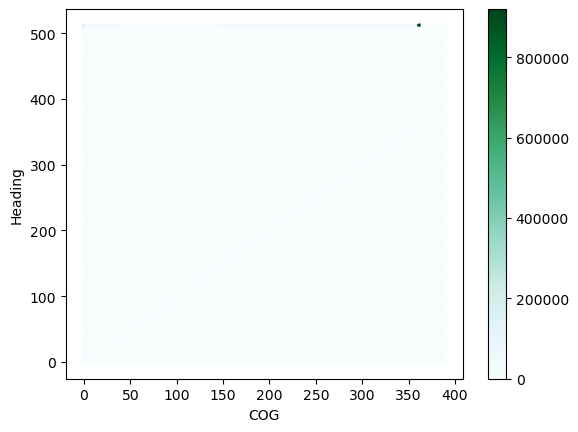

In [30]:
ais_ships_df.plot(kind='hexbin',x='COG',y='Heading')

In [31]:
ais_ships_df.groupby(['COG','Heading']).count().MMSI.sort_values(ascending=False)

COG    Heading
360.0  511.0      917224
0.0    511.0      116752
       1.0          2605
298.7  511.0        2591
270.0  511.0        2531
                   ...  
85.7   355.0           1
       356.0           1
       358.0           1
85.8   0.0             1
388.8  318.0           1
Name: MMSI, Length: 845058, dtype: int64

COG 360 Heading 511, invalid both ways? but other headings 511 look like they have valid COG.

<AxesSubplot: xlabel='COG', ylabel='Heading'>

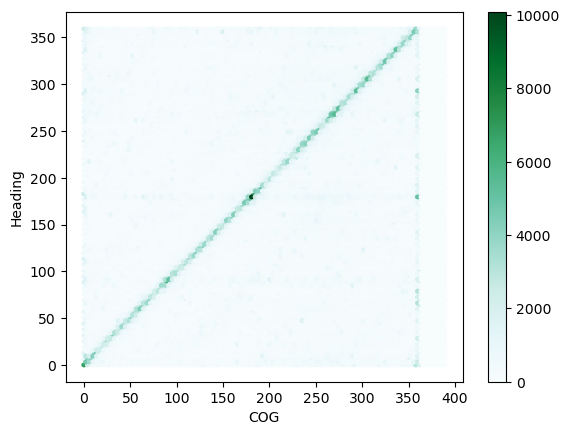

In [32]:
ais_ships_df.query('Heading<511').plot(kind='hexbin',x='COG',y='Heading')

In [33]:
ais_ships_df.query('Heading<511').groupby(['COG','Heading']).count().MMSI.sort_values(ascending=False)

COG    Heading
0.0    1.0        2605
360.0  293.0      2485
0.0    0.0        1747
360.0  179.0      1567
0.0    10.0       1422
                  ... 
123.0  160.0         1
       164.0         1
       167.0         1
       168.0         1
388.8  318.0         1
Name: MMSI, Length: 841456, dtype: int64

## Scatterplot maps

<AxesSubplot: xlabel='LON', ylabel='LAT'>

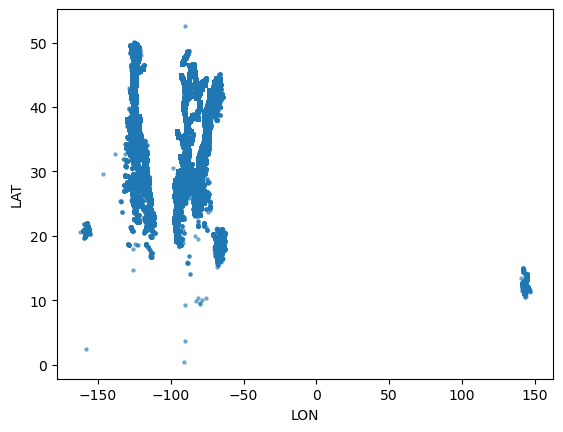

In [34]:
(ais_ships_df
 [['LON','LAT']]
 .plot(kind='scatter',x='LON',y='LAT', alpha=0.5, marker='.')
)

Where is Alaska?

### Guam?

<AxesSubplot: xlabel='LON', ylabel='LAT'>

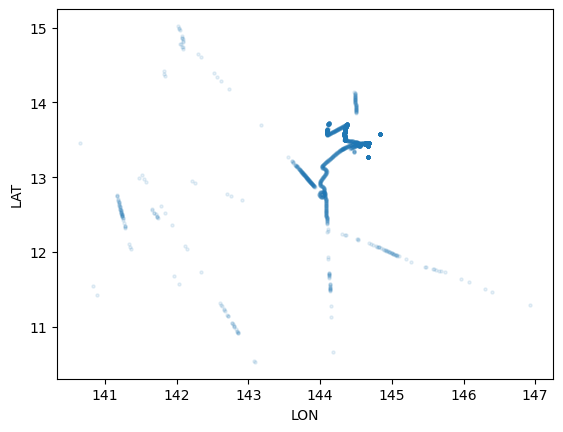

In [35]:
(ais_ships_df
 [['LON','LAT']]
 .query('LON>0')
 .plot(kind='scatter',x='LON',y='LAT', alpha=0.1, marker='.')
)

### CONUS Puerto Rico and Hawaii

<AxesSubplot: xlabel='LON', ylabel='LAT'>

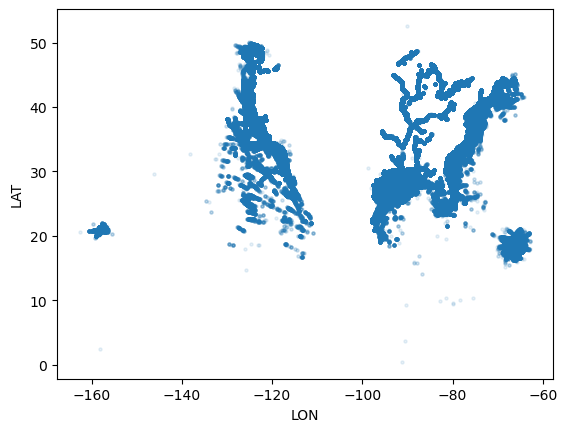

In [36]:
(ais_ships_df
 [['LON','LAT']]
 .query('LON<0')
 .plot(kind='scatter',x='LON',y='LAT', alpha=0.1, marker='.')
)

### CONUS + Puerto Rico

<AxesSubplot: xlabel='LON', ylabel='LAT'>

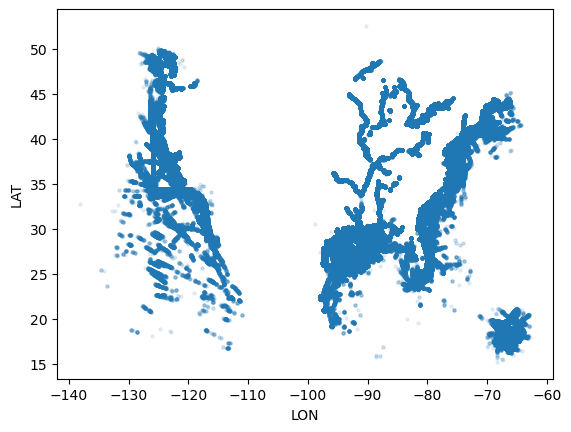

In [37]:
(ais_ships_df
 [['LON','LAT']]
 .query('LON<0 and LON>-140 and LAT>15')
 .plot(kind='scatter',x='LON',y='LAT', alpha=0.1, marker='.')
)